## 0. Setup

In [24]:
# =========================
# Cell 1: Setup
# =========================

from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

# -------------------------
# Paths
# -------------------------
REPO_ROOT = Path("/home/pirie03/projects/aip-medilab/pirie03/NeedleMicroSeg")
DATA_ROOT = Path("/project/6106383/shared/2026-03-11_pwilson_needle-fire-needle-mask")
SPLITS_FILE = REPO_ROOT / "dataset" / "multicenter_custom_split.json"
SPLIT_ID = "multicenter_custom"
SPLIT = "val"

CKPT_2D = REPO_ROOT / "runs_2d" / "full_frame_resize_test_2567085" / "checkpoint_best.pt"
CKPT_3D = REPO_ROOT / "runs_3d" / "full_frame_resize_test_2597871" / "checkpoint_best.pt"

RUN_CONFIG_2D = CKPT_2D.parent / "config.json"
RUN_CONFIG_3D = CKPT_3D.parent / "config.json"

# -------------------------
# Repo imports
# -------------------------
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.dataset_2d import NeedleDataset2D
from src.data.dataset_3d import NeedleDataset3D
from src.data.extractors_2d import get_extractor as get_extractor_2d
from src.data.extractors_3d import get_extractor as get_extractor_3d
from src.models.unet_2d import build_unet_2d
from src.models.unet_3d import build_unet_3d
from src.utils.normalization import get_normalizer

# -------------------------
# Device / reproducibility
# -------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Optional nicer dataframe display in notebook
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

Using device: cuda


In [25]:
# =========================
# Cell 2: Config + checkpoint helpers
# =========================

import re

# def remap_2d_checkpoint_keys(state_dict):
#     remapped = {}
#     for k, v in state_dict.items():
#         new_k = re.sub(r"\.sub(\d+)\.", r".submodule.\1.", k)
#         remapped[new_k] = v
#     return remapped

def load_json(path):
    path = Path(path)
    with open(path, "r") as f:
        return json.load(f)


def load_checkpoint(path, map_location="cpu"):
    path = Path(path)
    ckpt = torch.load(path, map_location=map_location)
    return ckpt


def extract_state_dict(ckpt):
    """
    Handles common checkpoint formats:
    - raw state_dict
    - {'model_state_dict': ...}
    - {'state_dict': ...}
    """
    if isinstance(ckpt, dict):
        if "model_state_dict" in ckpt:
            return ckpt["model_state_dict"]
        if "state_dict" in ckpt:
            return ckpt["state_dict"]
    return ckpt


In [26]:
# =========================
# Cell 3: Model builders
# =========================

def build_model_2d_from_run_config(run_cfg):
    model_cfg = run_cfg["model"]
    model, meta = build_unet_2d(
        in_channels=model_cfg["in_channels"],
        out_channels=model_cfg["out_channels"],
        variant=model_cfg["model_variant"],
    )
    return model


def build_model_3d_from_run_config(run_cfg):
    model_cfg = run_cfg["model"]
    model, meta = build_unet_3d(
        in_channels=model_cfg["in_channels"],
        out_channels=model_cfg["out_channels"],
        variant=model_cfg["model_variant"],
    )
    return model


def load_model_weights(model, ckpt_path, device=DEVICE, verbose=True):
    ckpt = load_checkpoint(ckpt_path, map_location=device)
    state_dict = extract_state_dict(ckpt)
    # state_dict = clean_state_dict_keys(state_dict)

    # if remap_2d_keys:
    #     state_dict = remap_2d_checkpoint_keys(state_dict)

    incompatible = model.load_state_dict(state_dict, strict=False)

    model.to(device)
    model.eval()

    if verbose:
        print(f"Loaded weights from: {ckpt_path}")
        print(f"Num checkpoint tensors: {len(state_dict)}")
        print(f"Missing keys: {len(incompatible.missing_keys)}")
        print(f"Unexpected keys: {len(incompatible.unexpected_keys)}")

        if len(incompatible.missing_keys) > 0:
            print("First few missing keys:", incompatible.missing_keys[:10])
        if len(incompatible.unexpected_keys) > 0:
            print("First few unexpected keys:", incompatible.unexpected_keys[:10])

    return model

# =========================
# Cell 4: Dataset builders
# =========================

def get_run_components_2d(run_cfg):
    train_cfg = run_cfg["train_config"]

    extractor_name = train_cfg["extractor"]["name"]
    extractor_kwargs = train_cfg["extractor"].get("kwargs", {})
    normalizer_name = train_cfg.get("normalization", {}).get("name", None)

    extractor_fn = get_extractor_2d(extractor_name)
    normalizer = get_normalizer(normalizer_name)

    return extractor_fn, extractor_kwargs, normalizer


def get_run_components_3d(run_cfg):
    train_cfg = run_cfg["train_config"]

    extractor_name = train_cfg["extractor"]["name"]
    extractor_kwargs = train_cfg["extractor"].get("kwargs", {})
    normalizer_name = train_cfg.get("normalization", {}).get("name", None)

    extractor_fn = get_extractor_3d(extractor_name)
    normalizer = get_normalizer(normalizer_name)

    return extractor_fn, extractor_kwargs, normalizer


def build_inference_dataset_2d(
    run_cfg,
    data_root=DATA_ROOT,
    splits_file=SPLITS_FILE,
    split=SPLIT,
    split_id=SPLIT_ID,
):
    extractor_fn, extractor_kwargs, normalizer = get_run_components_2d(run_cfg)

    ds = NeedleDataset2D(
        root=data_root,
        split=split,
        split_id=split_id,
        splits_file=splits_file,
        extractor_fn=extractor_fn,
        extractor_kwargs=extractor_kwargs,
        normalizer=normalizer,
        transform=None,              # no augmentations at inference
        return_metadata=True,
    )
    return ds


def build_inference_dataset_3d(
    run_cfg,
    data_root=DATA_ROOT,
    splits_file=SPLITS_FILE,
    split=SPLIT,
    split_id=SPLIT_ID,
):
    extractor_fn, extractor_kwargs, normalizer = get_run_components_3d(run_cfg)

    ds = NeedleDataset3D(
        root=data_root,
        split=split,
        split_id=split_id,
        splits_file=splits_file,
        extractor_fn=extractor_fn,
        extractor_kwargs=extractor_kwargs,
        normalizer=normalizer,
        transform=None,              # no augmentations at inference
        return_metadata=True,
    )
    return ds

In [27]:
# =========================
# Cell 5: Metrics + display helpers
# =========================

def sigmoid_to_binary_mask(logits, threshold=0.5):
    """
    logits: torch.Tensor, shape (..., H, W)
    returns uint8 numpy array of shape (..., H, W)
    """
    probs = torch.sigmoid(logits)
    pred = (probs >= threshold).to(torch.uint8)
    return pred.detach().cpu().numpy()


def dice_score_binary(pred, target, eps=1e-8):
    """
    pred, target: numpy arrays with values {0,1}, shape (H,W)
    """
    pred = pred.astype(np.uint8)
    target = target.astype(np.uint8)

    intersection = (pred & target).sum()
    denom = pred.sum() + target.sum()

    if denom == 0:
        return 1.0

    return float((2.0 * intersection + eps) / (denom + eps))


def normalize_image_for_display(image):
    """
    Robust min-max scaling for display.
    image: numpy array (H,W)
    """
    image = np.asarray(image, dtype=np.float32)

    lo = np.percentile(image, 1)
    hi = np.percentile(image, 99)

    if hi <= lo:
        lo = image.min()
        hi = image.max()

    if hi <= lo:
        return np.zeros_like(image, dtype=np.float32)

    image = np.clip(image, lo, hi)
    image = (image - lo) / (hi - lo)
    return image.astype(np.float32)


def ensure_numpy_2d(x):
    """
    Converts torch/numpy arrays shaped like:
    (1,H,W), (H,W), etc. -> (H,W)
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    x = np.asarray(x)

    if x.ndim == 3 and x.shape[0] == 1:
        x = x[0]

    return x


def resize_mask_to_shape(mask, out_shape):
    """
    Nearest-neighbor resize for binary/categorical masks.
    mask: (H,W) numpy array
    out_shape: (H_out, W_out)
    """
    mask_t = torch.as_tensor(mask[None, None, ...]).float()
    resized = F.interpolate(mask_t, size=out_shape, mode="nearest")
    return resized[0, 0].cpu().numpy()


def resize_image_to_shape(image, out_shape):
    """
    Bilinear resize for grayscale images.
    image: (H,W) numpy array
    out_shape: (H_out, W_out)
    """
    image_t = torch.as_tensor(image[None, None, ...]).float()
    resized = F.interpolate(image_t, size=out_shape, mode="bilinear", align_corners=False)
    return resized[0, 0].cpu().numpy()

In [28]:
# =========================
# Cell 6: Error/disagreement maps
# =========================

def make_gt_vs_pred_map(gt, pred):
    """
    Returns categorical map:
    0 = true negative / background
    1 = true positive
    2 = false negative
    3 = false positive
    """
    gt = ensure_numpy_2d(gt).astype(np.uint8)
    pred = ensure_numpy_2d(pred).astype(np.uint8)

    out = np.zeros_like(gt, dtype=np.uint8)
    out[(gt == 1) & (pred == 1)] = 1
    out[(gt == 1) & (pred == 0)] = 2
    out[(gt == 0) & (pred == 1)] = 3
    return out


def make_pred_vs_pred_map(pred_2d, pred_3d):
    """
    Returns categorical map:
    0 = both background
    1 = both positive
    2 = 2D only
    3 = 3D only
    """
    pred_2d = ensure_numpy_2d(pred_2d).astype(np.uint8)
    pred_3d = ensure_numpy_2d(pred_3d).astype(np.uint8)

    out = np.zeros_like(pred_2d, dtype=np.uint8)
    out[(pred_2d == 1) & (pred_3d == 1)] = 1
    out[(pred_2d == 1) & (pred_3d == 0)] = 2
    out[(pred_2d == 0) & (pred_3d == 1)] = 3
    return out


GT_PRED_CMAP = ListedColormap([
    "black",        # 0 background
    "limegreen",    # 1 TP
    "deepskyblue",  # 2 FN
    "red",          # 3 FP
])

PRED_PRED_CMAP = ListedColormap([
    "black",        # 0 both background
    "white",        # 1 both positive
    "gold",         # 2 2D only
    "magenta",      # 3 3D only
])

In [29]:
# =========================
# Cell 7: Plotting helpers
# =========================

def show_binary_mask(ax, mask, title="", cmap="gray"):
    mask = ensure_numpy_2d(mask)
    ax.imshow(mask, cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")


def show_frame(ax, image, title=""):
    image = normalize_image_for_display(ensure_numpy_2d(image))
    ax.imshow(image, cmap="gray", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")


def show_categorical_map(ax, cat_map, title="", cmap=None, vmin=0, vmax=3):
    cat_map = ensure_numpy_2d(cat_map)
    ax.imshow(cat_map, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")


def plot_single_model_case(case_dict, model_name="2D", figsize=(12, 3.5)):
    """
    case_dict expected keys:
    - image
    - gt
    - pred
    - dice
    - h5_path
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    show_frame(axes[0], case_dict["image"], title="Frame")
    show_binary_mask(axes[1], case_dict["gt"], title="GT")
    show_binary_mask(axes[2], case_dict["pred"], title=f"{model_name} Pred")

    err_map = make_gt_vs_pred_map(case_dict["gt"], case_dict["pred"])
    show_categorical_map(
        axes[3],
        err_map,
        title=f"GT vs {model_name}",
        cmap=GT_PRED_CMAP,
        vmin=0,
        vmax=3,
    )

    fig.suptitle(
        f"{model_name} | Dice={case_dict['dice']:.4f}\n{Path(case_dict['h5_path']).name}",
        y=1.02
    )
    plt.tight_layout()
    plt.show()


def plot_paired_case(case_2d, case_3d, resize_to="2d", figsize=(18, 5)):
    """
    Shows:
    frame | GT | 2D pred | 3D pred | GT vs 2D | GT vs 3D | 2D vs 3D

    resize_to:
    - "2d" -> resize 3D items to 2D shape
    - "3d" -> resize 2D items to 3D shape
    """
    image_2d = ensure_numpy_2d(case_2d["image"])
    gt_2d = ensure_numpy_2d(case_2d["gt"]).astype(np.uint8)
    pred_2d = ensure_numpy_2d(case_2d["pred"]).astype(np.uint8)

    image_3d = ensure_numpy_2d(case_3d["image"])
    gt_3d = ensure_numpy_2d(case_3d["gt"]).astype(np.uint8)
    pred_3d = ensure_numpy_2d(case_3d["pred"]).astype(np.uint8)

    if resize_to == "2d":
        target_shape = image_2d.shape
        image = image_2d
        gt = gt_2d
        pred2 = pred_2d

        image3 = resize_image_to_shape(image_3d, target_shape)
        gt3 = resize_mask_to_shape(gt_3d, target_shape).astype(np.uint8)
        pred3 = resize_mask_to_shape(pred_3d, target_shape).astype(np.uint8)

    elif resize_to == "3d":
        target_shape = image_3d.shape
        image = resize_image_to_shape(image_2d, target_shape)
        gt = resize_mask_to_shape(gt_2d, target_shape).astype(np.uint8)
        pred2 = resize_mask_to_shape(pred_2d, target_shape).astype(np.uint8)

        image3 = image_3d
        gt3 = gt_3d
        pred3 = pred_3d
    else:
        raise ValueError("resize_to must be '2d' or '3d'")

    # Use a single displayed frame/GT to keep panel clean
    # If resizing to 2D, use 2D frame/GT; if resizing to 3D, use 3D frame/GT
    disp_image = image if resize_to == "2d" else image3
    disp_gt = gt if resize_to == "2d" else gt3

    gt_vs_2d = make_gt_vs_pred_map(disp_gt, pred2)
    gt_vs_3d = make_gt_vs_pred_map(disp_gt, pred3)
    pred_vs_pred = make_pred_vs_pred_map(pred2, pred3)

    fig, axes = plt.subplots(1, 7, figsize=figsize)

    show_frame(axes[0], disp_image, title="Frame")
    show_binary_mask(axes[1], disp_gt, title="GT")
    show_binary_mask(axes[2], pred2, title=f"2D Pred\nDice={case_2d['dice']:.4f}")
    show_binary_mask(axes[3], pred3, title=f"3D Pred\nDice={case_3d['dice']:.4f}")

    show_categorical_map(axes[4], gt_vs_2d, title="GT vs 2D", cmap=GT_PRED_CMAP)
    show_categorical_map(axes[5], gt_vs_3d, title="GT vs 3D", cmap=GT_PRED_CMAP)
    show_categorical_map(axes[6], pred_vs_pred, title="2D vs 3D", cmap=PRED_PRED_CMAP)

    fig.suptitle(Path(case_2d["h5_path"]).name, y=1.02)
    plt.tight_layout()
    plt.show()

# =========================
# Cell 8: Quick sanity check
# =========================

run_cfg_2d = load_json(RUN_CONFIG_2D)
run_cfg_3d = load_json(RUN_CONFIG_3D)

print("2D model variant:", run_cfg_2d["model"]["model_variant"])
print("2D extractor:", run_cfg_2d["train_config"]["extractor"])

print("3D model variant:", run_cfg_3d["model"]["model_variant"])
print("3D extractor:", run_cfg_3d["train_config"]["extractor"])

2D model variant: base
2D extractor: {'name': 'full_frame_resize', 'kwargs': {'out_hw': [256, 256]}}
3D model variant: base
3D extractor: {'name': 'temporal_window', 'kwargs': {'z_window': 8, 'out_hw': [256, 256]}}


## 1. Load Models

In [30]:
# =========================
# Cell 9: Load 2D model + dataset
# =========================

run_cfg_2d = load_json(RUN_CONFIG_2D)

model_2d = build_model_2d_from_run_config(run_cfg_2d)
model_2d = load_model_weights(
    model_2d,
    CKPT_2D,
    device=DEVICE,
    verbose=True
)

ds_2d = build_inference_dataset_2d(
    run_cfg_2d,
    data_root=DATA_ROOT,
    splits_file=SPLITS_FILE,
    split=SPLIT,
    split_id=SPLIT_ID,
)

print("2D dataset size:", len(ds_2d))

sample_2d = ds_2d[0]
print("2D sample keys:", list(sample_2d.keys()))
print("2D image shape:", tuple(sample_2d["image"].shape))
print("2D mask shape:", tuple(sample_2d["mask"].shape))
print("2D h5_path:", sample_2d["h5_path"])
print("2D cine_id:", sample_2d["cine_id"])

Loaded weights from: /home/pirie03/projects/aip-medilab/pirie03/NeedleMicroSeg/runs_2d/full_frame_resize_test_2567085/checkpoint_best.pt
Num checkpoint tensors: 44
Missing keys: 0
Unexpected keys: 0
2D dataset size: 339
2D sample keys: ['image', 'mask', 'metadata', 'cine_id', 'needle_mask_annotation_index', 'h5_path']
2D image shape: (1, 256, 256)
2D mask shape: (1, 256, 256)
2D h5_path: /project/6106383/shared/2026-03-11_pwilson_needle-fire-needle-mask/data/OL-009-007.h5
2D cine_id: OL-009-007


In [31]:
# =========================
# Cell 10: Load 3D model + dataset
# =========================

run_cfg_3d = load_json(RUN_CONFIG_3D)

model_3d = build_model_3d_from_run_config(run_cfg_3d)
model_3d = load_model_weights(model_3d, CKPT_3D, device=DEVICE, verbose=True)

ds_3d = build_inference_dataset_3d(
    run_cfg_3d,
    data_root=DATA_ROOT,
    splits_file=SPLITS_FILE,
    split=SPLIT,
    split_id=SPLIT_ID,
)

print("3D dataset size:", len(ds_3d))

sample_3d = ds_3d[0]
print("3D sample keys:", list(sample_3d.keys()))
print("3D image shape:", tuple(sample_3d["image"].shape))
print("3D mask shape:", tuple(sample_3d["mask"].shape))
print("3D center_index:", sample_3d["center_index"])
print("3D h5_path:", sample_3d["h5_path"])
print("3D cine_id:", sample_3d["cine_id"])

Loaded weights from: /home/pirie03/projects/aip-medilab/pirie03/NeedleMicroSeg/runs_3d/full_frame_resize_test_2597871/checkpoint_best.pt
Num checkpoint tensors: 66
Missing keys: 0
Unexpected keys: 0
3D dataset size: 339
3D sample keys: ['image', 'mask', 'metadata', 'cine_id', 'needle_mask_annotation_index', 'center_index', 'h5_path']
3D image shape: (1, 8, 256, 256)
3D mask shape: (1, 256, 256)
3D center_index: 4
3D h5_path: /project/6106383/shared/2026-03-11_pwilson_needle-fire-needle-mask/data/OL-009-007.h5
3D cine_id: OL-009-007


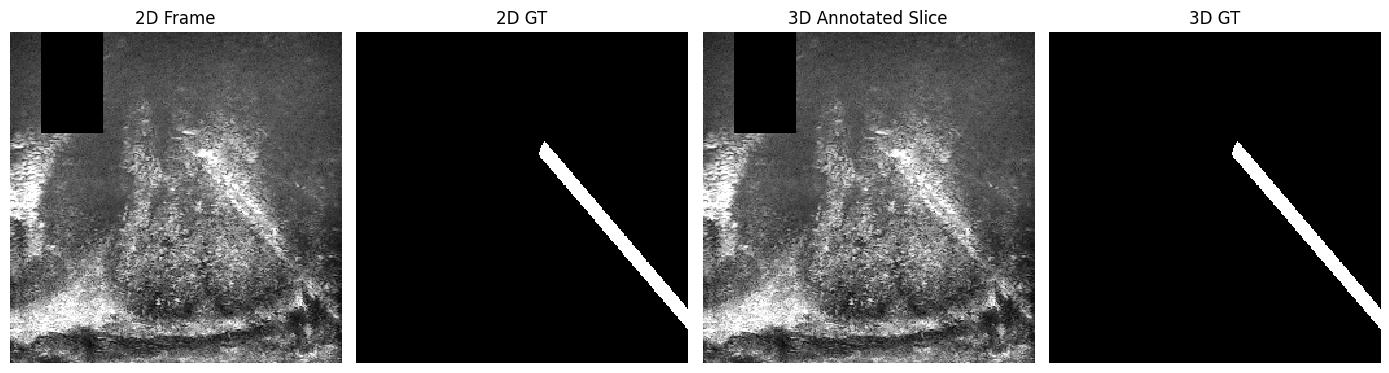

In [32]:
# =========================
# Cell 11: Quick sample sanity plots
# =========================

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# 2D
show_frame(axes[0], sample_2d["image"], title="2D Frame")
show_binary_mask(axes[1], sample_2d["mask"], title="2D GT")

# 3D annotated slice
img_3d = ensure_numpy_2d(sample_3d["image"][0, sample_3d["center_index"], :, :])
show_frame(axes[2], img_3d, title="3D Annotated Slice")
show_binary_mask(axes[3], sample_3d["mask"], title="3D GT")

plt.tight_layout()
plt.show()

## 2. Run Inference

In [33]:
# =========================
# Cell 12: Run 2D inference
# =========================

@torch.no_grad()
def run_inference_2d(model, dataset, device=DEVICE, threshold=0.5):
    results = []

    model.eval()

    for idx in range(len(dataset)):
        sample = dataset[idx]

        image = sample["image"].unsqueeze(0).to(device)   # (1, 1, H, W)
        gt = ensure_numpy_2d(sample["mask"]).astype(np.uint8)

        logits = model(image)                             # expected (1, 1, H, W)
        pred = sigmoid_to_binary_mask(logits, threshold=threshold)[0, 0].astype(np.uint8)

        disp_image = ensure_numpy_2d(sample["image"])

        result = {
            "sample_idx": idx,
            "h5_path": sample["h5_path"],
            "cine_id": sample["cine_id"],
            "needle_mask_annotation_index": sample["needle_mask_annotation_index"],
            "image": disp_image,
            "gt": gt,
            "pred": pred,
            "dice": dice_score_binary(pred, gt),
        }
        results.append(result)

    return results


results_2d = run_inference_2d(model_2d, ds_2d, device=DEVICE, threshold=0.5)

print("Number of 2D results:", len(results_2d))
print("First 2D result keys:", list(results_2d[0].keys()))
print("First 2D result file:", Path(results_2d[0]["h5_path"]).name)
print("First 2D result dice:", results_2d[0]["dice"])

Number of 2D results: 339
First 2D result keys: ['sample_idx', 'h5_path', 'cine_id', 'needle_mask_annotation_index', 'image', 'gt', 'pred', 'dice']
First 2D result file: OL-009-007.h5
First 2D result dice: 0.9179864253395984


In [34]:
# =========================
# Cell 13: Run 3D inference
# =========================

@torch.no_grad()
def run_inference_3d(model, dataset, device=DEVICE, threshold=0.5):
    results = []

    model.eval()

    for idx in range(len(dataset)):
        sample = dataset[idx]

        image = sample["image"].unsqueeze(0).to(device)   # (1, 1, Z, H, W)
        gt = ensure_numpy_2d(sample["mask"]).astype(np.uint8)
        center_index = int(sample["center_index"])

        logits = model(image)                             # expected (1, 1, Z, H, W)
        logits_center = logits[:, :, center_index, :, :]  # (1, 1, H, W)

        pred = sigmoid_to_binary_mask(logits_center, threshold=threshold)[0, 0].astype(np.uint8)

        disp_image = ensure_numpy_2d(sample["image"][0, center_index, :, :])

        result = {
            "sample_idx": idx,
            "h5_path": sample["h5_path"],
            "cine_id": sample["cine_id"],
            "needle_mask_annotation_index": sample["needle_mask_annotation_index"],
            "center_index": center_index,
            "image": disp_image,
            "gt": gt,
            "pred": pred,
            "dice": dice_score_binary(pred, gt),
        }
        results.append(result)

    return results


results_3d = run_inference_3d(model_3d, ds_3d, device=DEVICE, threshold=0.5)

print("Number of 3D results:", len(results_3d))
print("First 3D result keys:", list(results_3d[0].keys()))
print("First 3D result file:", Path(results_3d[0]["h5_path"]).name)
print("First 3D result dice:", results_3d[0]["dice"])

Number of 3D results: 339
First 3D result keys: ['sample_idx', 'h5_path', 'cine_id', 'needle_mask_annotation_index', 'center_index', 'image', 'gt', 'pred', 'dice']
First 3D result file: OL-009-007.h5
First 3D result dice: 0.9750271444083197


In [35]:
# =========================
# Cell 14: Build results tables
# =========================

df_2d = pd.DataFrame([
    {
        "sample_idx": r["sample_idx"],
        "h5_path": r["h5_path"],
        "file_name": Path(r["h5_path"]).name,
        "cine_id": r["cine_id"],
        "needle_mask_annotation_index": r["needle_mask_annotation_index"],
        "dice": r["dice"],
        "gt_area": int(np.asarray(r["gt"]).sum()),
        "pred_area": int(np.asarray(r["pred"]).sum()),
    }
    for r in results_2d
])

df_3d = pd.DataFrame([
    {
        "sample_idx": r["sample_idx"],
        "h5_path": r["h5_path"],
        "file_name": Path(r["h5_path"]).name,
        "cine_id": r["cine_id"],
        "needle_mask_annotation_index": r["needle_mask_annotation_index"],
        "center_index": r["center_index"],
        "dice": r["dice"],
        "gt_area": int(np.asarray(r["gt"]).sum()),
        "pred_area": int(np.asarray(r["pred"]).sum()),
    }
    for r in results_3d
])

display(df_2d.tail())
display(df_3d.tail())

print("2D mean dice:", df_2d["dice"].mean())
print("3D mean dice:", df_3d["dice"].mean())

,sample_idx,h5_path,file_name,cine_id,needle_mask_annotation_index,dice,gt_area,pred_area
334,334,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-014.h5,UA-155-014,59,0.627256,2046,1777
335,335,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-015.h5,UA-155-015,57,0.703771,2032,1813
336,336,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-016.h5,UA-155-016,55,0.864240,1824,1638
337,337,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-017.h5,UA-155-017,58,0.798283,1671,1591
338,338,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-018.h5,UA-155-018,56,0.892074,1910,1648


,sample_idx,h5_path,file_name,cine_id,needle_mask_annotation_index,center_index,dice,gt_area,pred_area
334,334,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-014.h5,UA-155-014,59,4,0.668736,2046,1498
335,335,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-015.h5,UA-155-015,57,4,0.696515,2032,1899
336,336,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-016.h5,UA-155-016,55,4,0.865248,1824,1701
337,337,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-017.h5,UA-155-017,58,4,0.808251,1671,1771
338,338,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-155-018.h5,UA-155-018,56,4,0.868428,1910,1685


2D mean dice: 0.8063761117712719
3D mean dice: 0.9000195207217518


In [41]:
# =========================
# Cell 15: Paired 2D vs 3D table
# =========================

df_pair = (
    df_2d[["h5_path", "file_name", "cine_id", "dice"]]
    .rename(columns={"dice": "dice_2d"})
    .merge(
        df_3d[["h5_path", "dice"]].rename(columns={"dice": "dice_3d"}),
        on="h5_path",
        how="inner",
    )
)

df_pair["dice_diff_3d_minus_2d"] = df_pair["dice_3d"] - df_pair["dice_2d"]

print("Number of matched 2D/3D samples:", len(df_pair))
display(df_pair.sort_values("dice_diff_3d_minus_2d", ascending=False).head())
display(df_pair.sort_values("dice_diff_3d_minus_2d", ascending=True).head())

Number of matched 2D/3D samples: 339


,h5_path,file_name,cine_id,dice_2d,dice_3d,dice_diff_3d_minus_2d
45,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-040-030.h5,OL-040-030,0.200526,0.960159,0.759633
105,/project/6106383/shared/2026-03-11_pwilson_nee...,PU-010-010.h5,PU-010-010,0.155141,0.767815,0.612674
44,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-040-029.h5,OL-040-029,0.156784,0.719595,0.562811
123,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-003-021.h5,UA-003-021,0.443213,0.921025,0.477812
41,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-040-026.h5,OL-040-026,0.494637,0.953076,0.458439


,h5_path,file_name,cine_id,dice_2d,dice_3d,dice_diff_3d_minus_2d
69,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-069-028.h5,OL-069-028,0.781653,0.522151,-0.259502
28,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-021-030.h5,OL-021-030,0.838555,0.666811,-0.171744
298,/project/6106383/shared/2026-03-11_pwilson_nee...,UA-113-011.h5,UA-113-011,0.776616,0.611007,-0.165609
63,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-069-022.h5,OL-069-022,0.874442,0.724228,-0.150214
57,/project/6106383/shared/2026-03-11_pwilson_nee...,OL-068-020.h5,OL-068-020,0.926639,0.804464,-0.122175


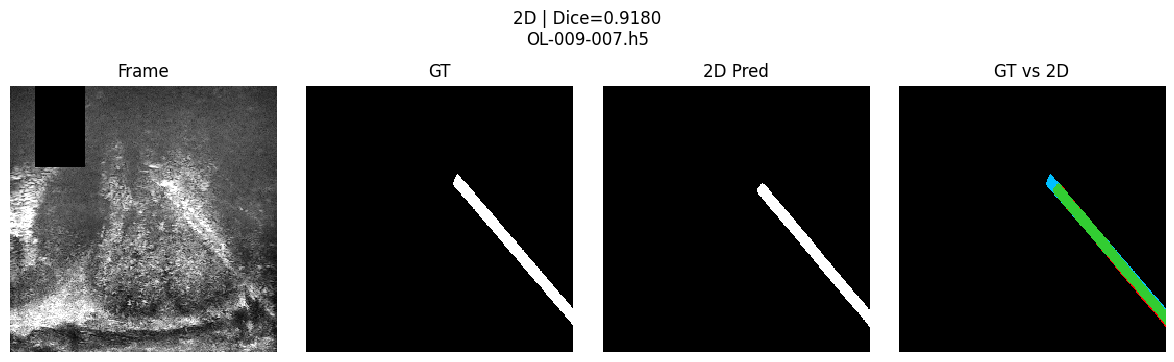

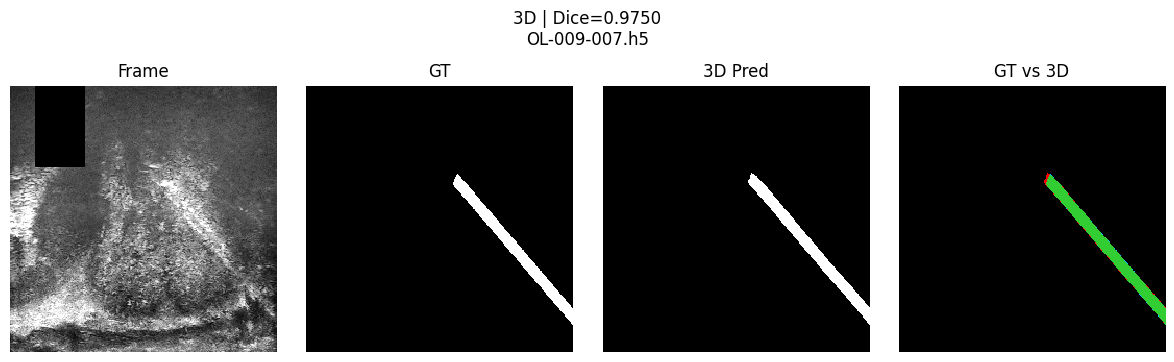

In [36]:
# =========================
# Cell 16: Quick sanity check plots from stored results
# =========================

plot_single_model_case(results_2d[0], model_name="2D")
plot_single_model_case(results_3d[0], model_name="3D")

## 3. Visualize

In [37]:
# =========================
# Cell 17: Lookup dictionaries
# =========================

results_2d_by_path = {r["h5_path"]: r for r in results_2d}
results_3d_by_path = {r["h5_path"]: r for r in results_3d}

print("2D lookup size:", len(results_2d_by_path))
print("3D lookup size:", len(results_3d_by_path))
print("Matched paths:", len(set(results_2d_by_path) & set(results_3d_by_path)))

2D lookup size: 339
3D lookup size: 339
Matched paths: 339


Top 3 best 2D


,file_name,dice,gt_area,pred_area
296,UA-113-009.h5,0.971539,1810,1809
223,UA-062-012.h5,0.964475,1973,1996
119,UA-003-017.h5,0.961805,1940,1961


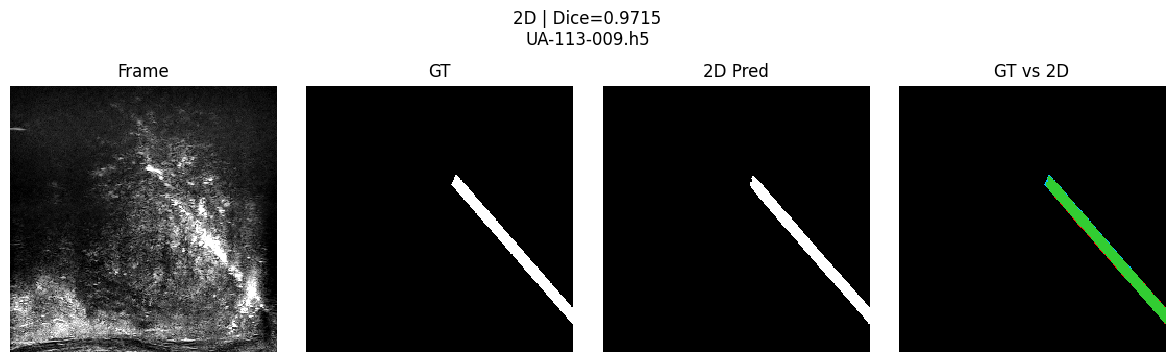

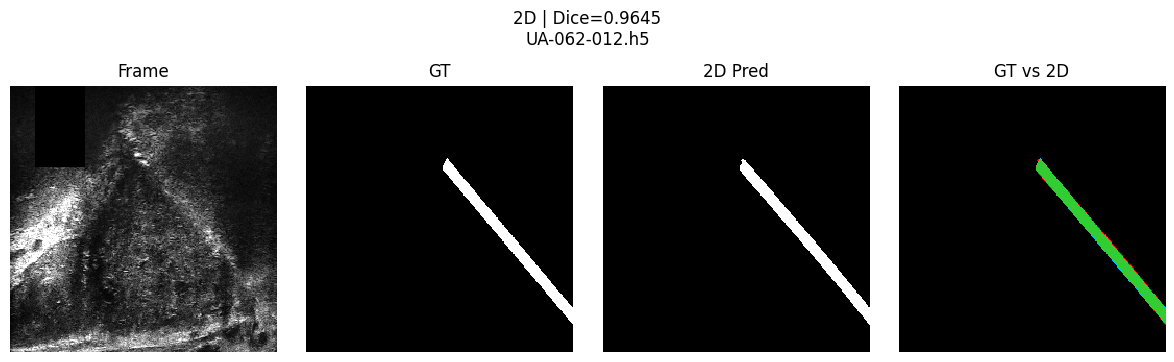

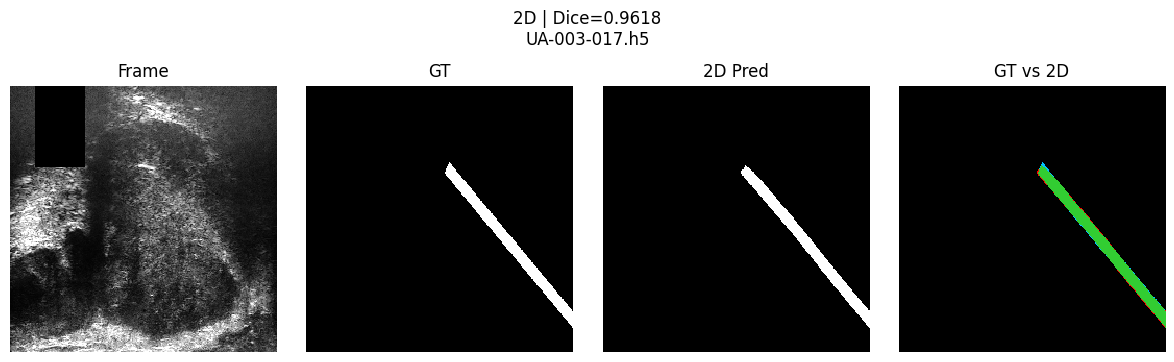

Top 3 worst 2D


,file_name,dice,gt_area,pred_area
106,PU-010-014.h5,0.097691,1909,1469
104,PU-010-009.h5,0.109933,1839,2218
105,PU-010-010.h5,0.155141,2123,1680


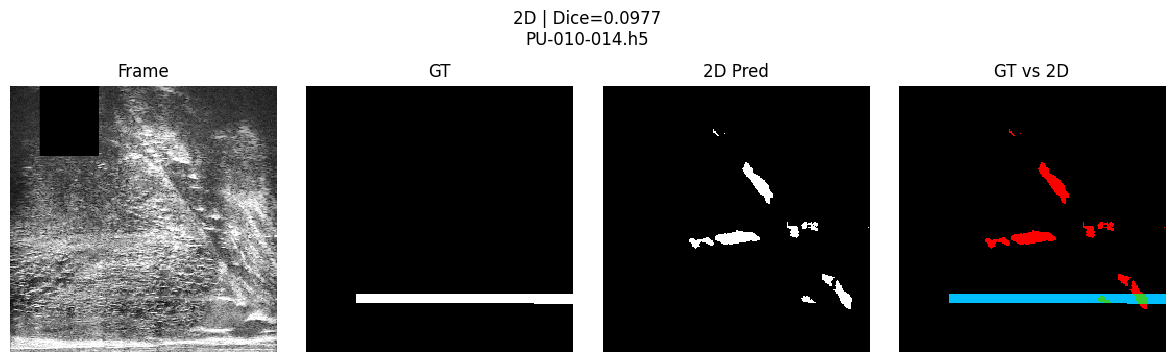

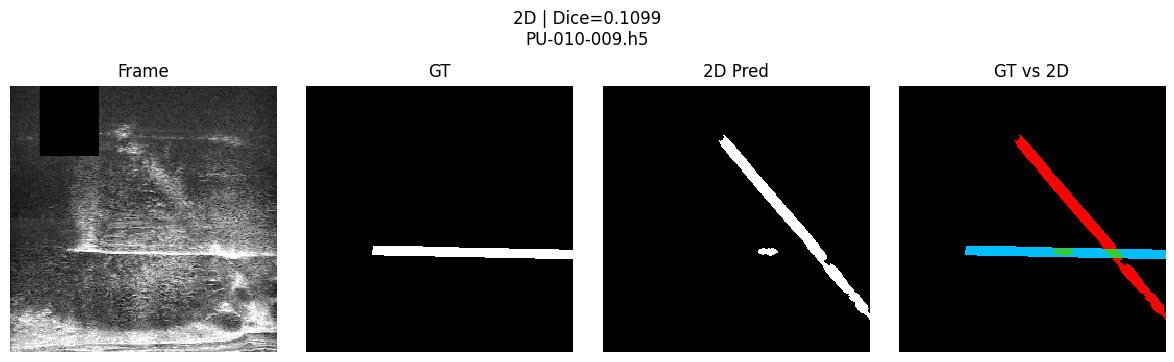

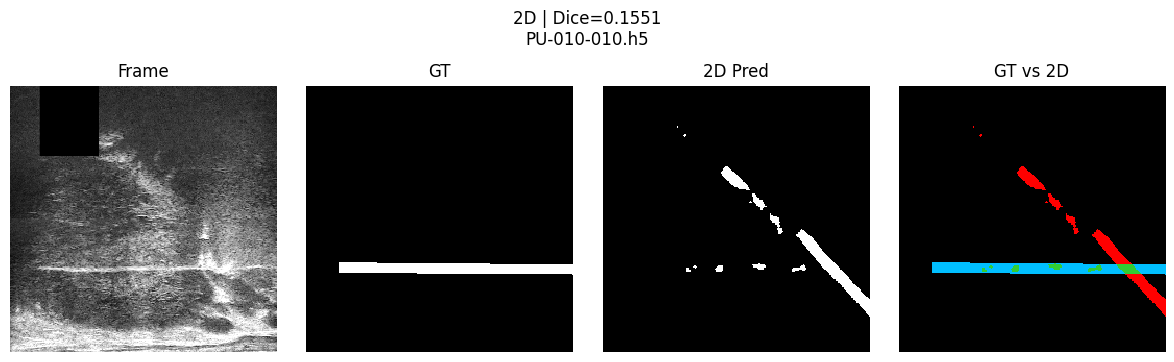

In [38]:
# =========================
# Cell 18: Top 3 best/worst 2D
# =========================

top3_best_2d = df_2d.sort_values("dice", ascending=False).head(3)
top3_worst_2d = df_2d.sort_values("dice", ascending=True).head(3)

print("Top 3 best 2D")
display(top3_best_2d[["file_name", "dice", "gt_area", "pred_area"]])

for _, row in top3_best_2d.iterrows():
    plot_single_model_case(results_2d_by_path[row["h5_path"]], model_name="2D")

print("Top 3 worst 2D")
display(top3_worst_2d[["file_name", "dice", "gt_area", "pred_area"]])

for _, row in top3_worst_2d.iterrows():
    plot_single_model_case(results_2d_by_path[row["h5_path"]], model_name="2D")

Top 3 best 3D


,file_name,dice,gt_area,pred_area
150,UA-024-017.h5,0.986372,1957,1932
228,UA-062-017.h5,0.985158,1777,1794
275,UA-085-004.h5,0.984060,2353,2352


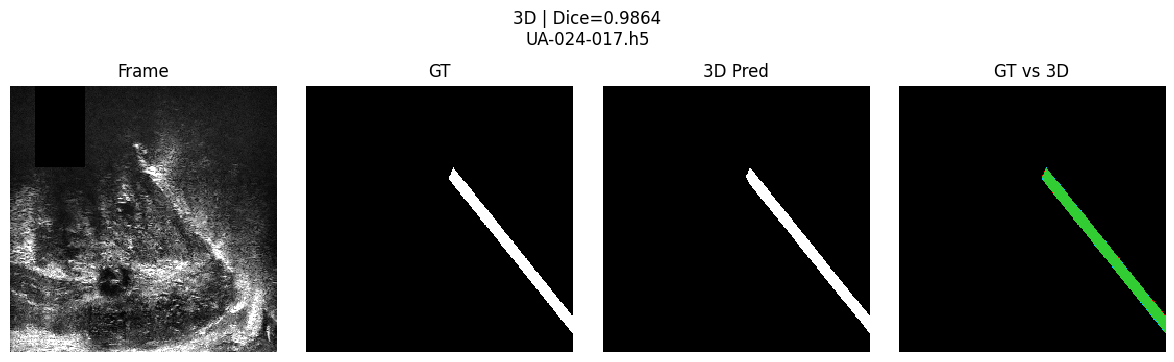

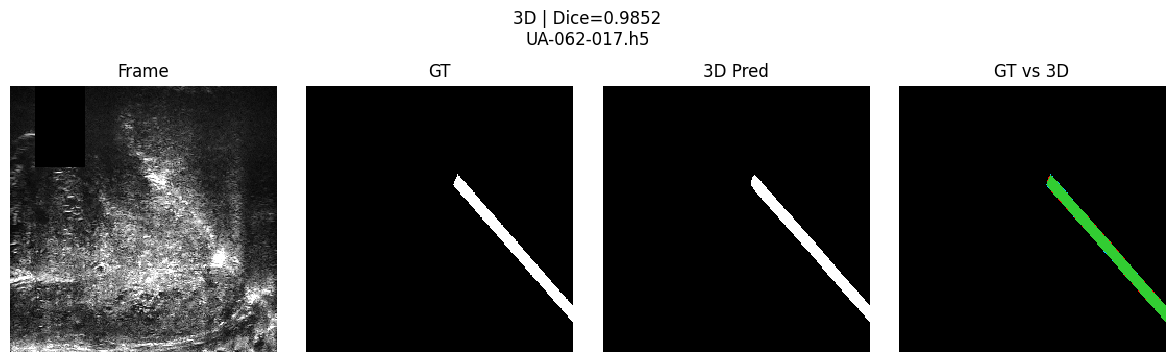

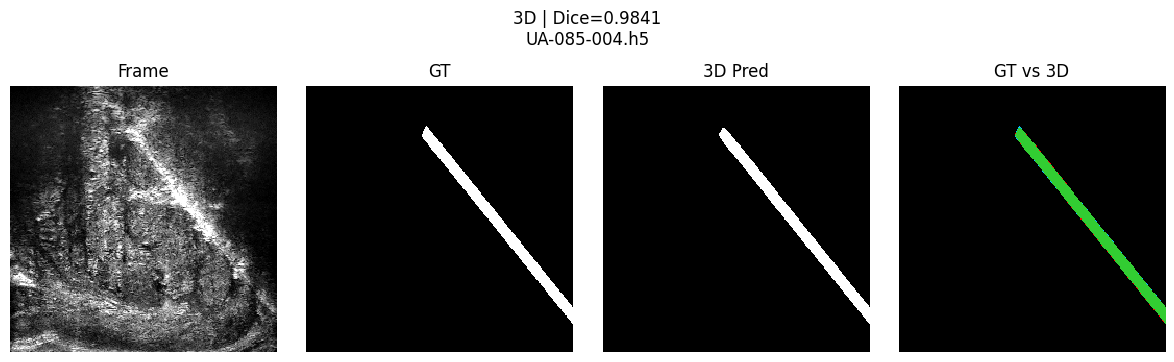

Top 3 worst 3D


,file_name,dice,gt_area,pred_area
106,PU-010-014.h5,0.085146,1909,252
303,UA-113-016.h5,0.342005,1788,826
68,OL-069-027.h5,0.420776,1541,1501


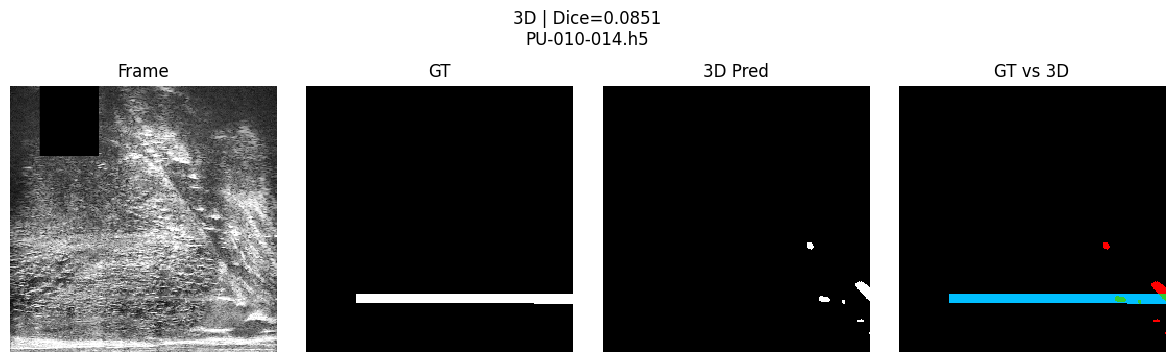

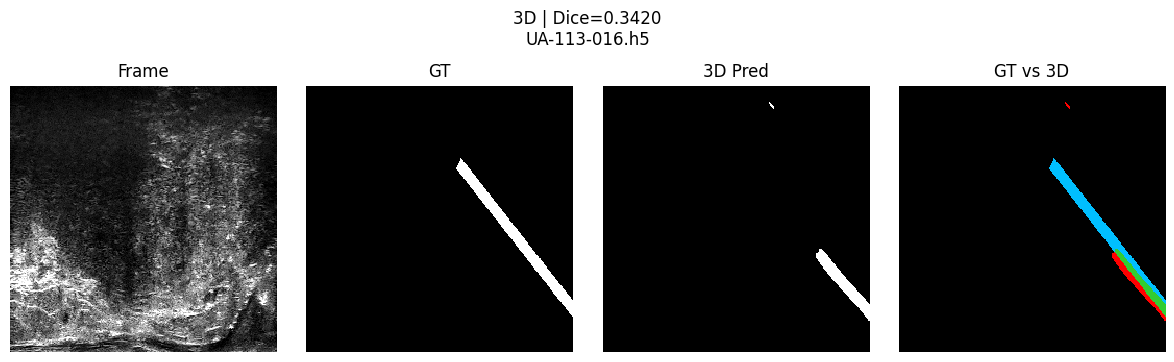

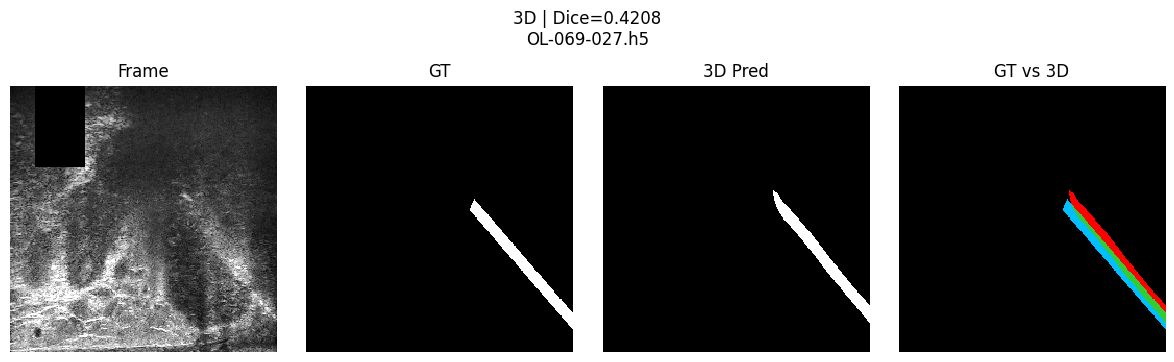

In [39]:
# =========================
# Cell 19: Top 3 best/worst 3D
# =========================

top3_best_3d = df_3d.sort_values("dice", ascending=False).head(3)
top3_worst_3d = df_3d.sort_values("dice", ascending=True).head(3)

print("Top 3 best 3D")
display(top3_best_3d[["file_name", "dice", "gt_area", "pred_area"]])

for _, row in top3_best_3d.iterrows():
    plot_single_model_case(results_3d_by_path[row["h5_path"]], model_name="3D")

print("Top 3 worst 3D")
display(top3_worst_3d[["file_name", "dice", "gt_area", "pred_area"]])

for _, row in top3_worst_3d.iterrows():
    plot_single_model_case(results_3d_by_path[row["h5_path"]], model_name="3D")

Random paired comparisons


,file_name,dice_2d,dice_3d,dice_diff_3d_minus_2d
76,OL-093-007.h5,0.843491,0.969502,0.126011
270,UA-075-017.h5,0.905382,0.971316,0.065933
224,UA-062-013.h5,0.944277,0.983580,0.039303


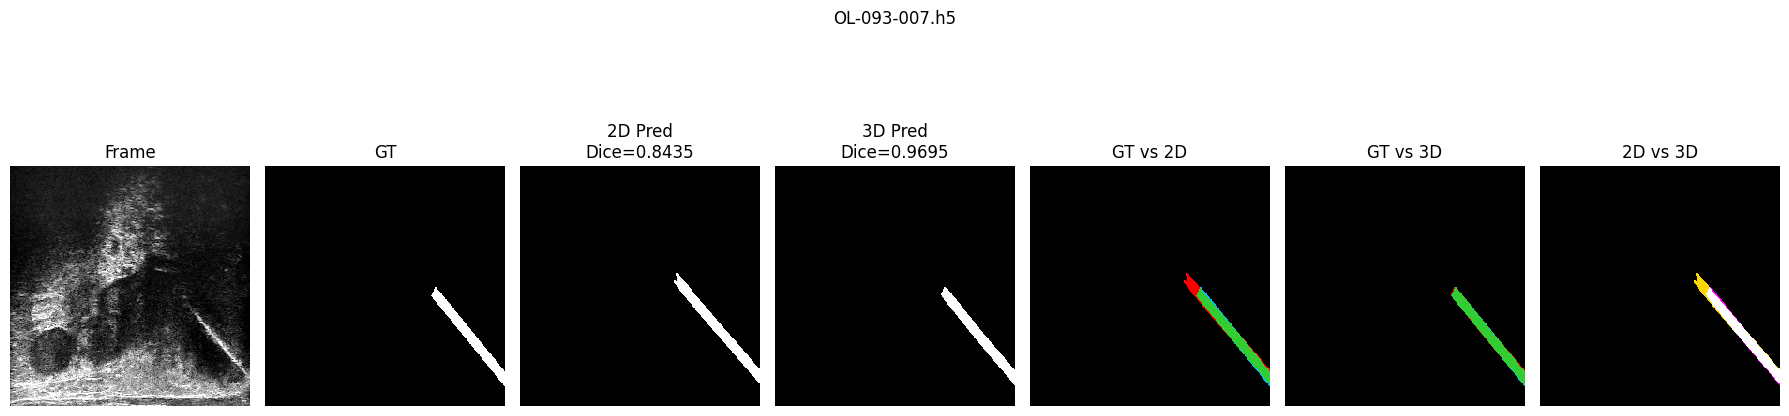

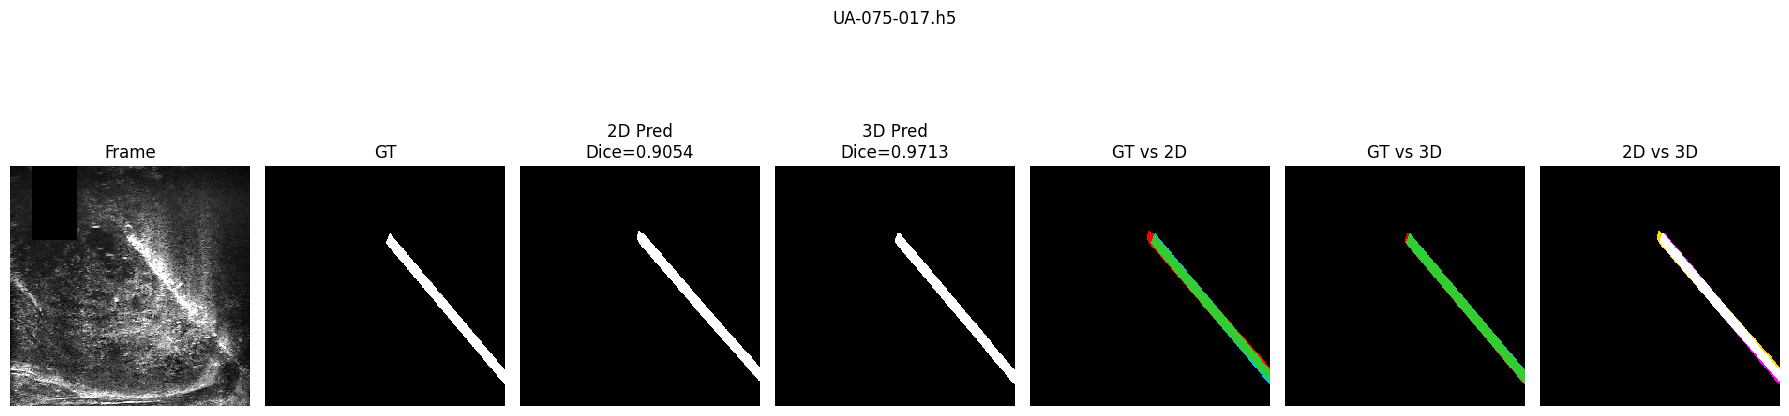

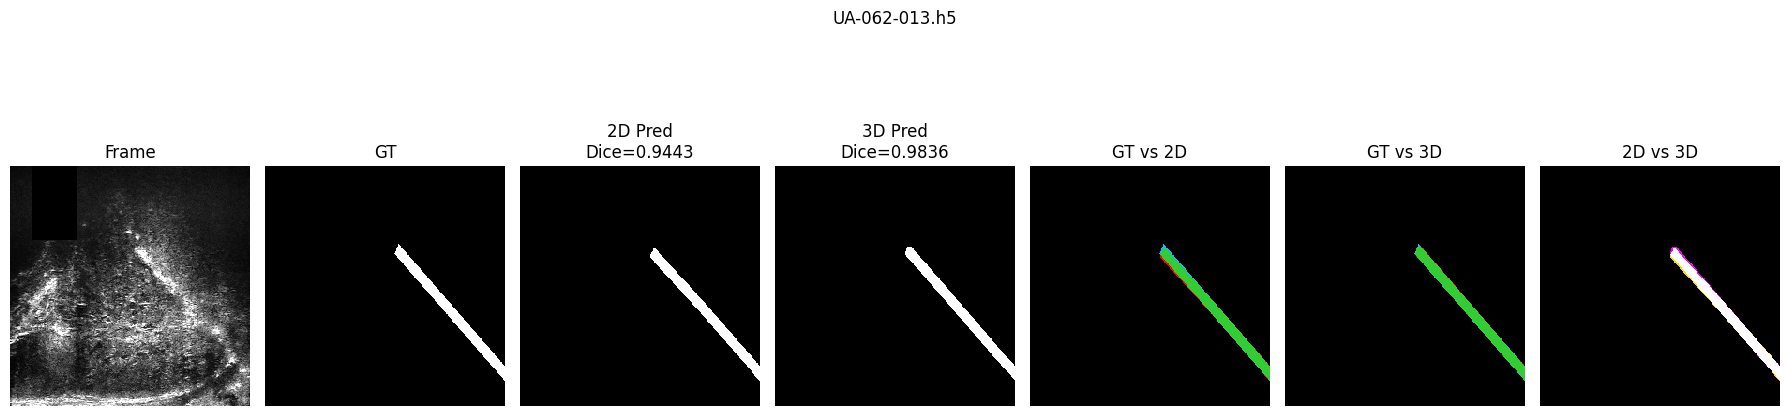

In [42]:
# =========================
# Cell 20: Random paired comparisons
# =========================

n_random = min(3, len(df_pair))
random_pair_df = df_pair.sample(n=n_random, random_state=SEED)

print("Random paired comparisons")
display(random_pair_df[["file_name", "dice_2d", "dice_3d", "dice_diff_3d_minus_2d"]])

for _, row in random_pair_df.iterrows():
    case_2d = results_2d_by_path[row["h5_path"]]
    case_3d = results_3d_by_path[row["h5_path"]]
    plot_paired_case(case_2d, case_3d, resize_to="2d")